In [1]:
import sqlite3
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
sb.set(style = "whitegrid")

In [3]:
conn = sqlite3.connect("Chinook_Sqlite.sqlite")

## Top Selling Products → *"Which tracks sell the most units overall?"*

In [24]:
query_tracks = """
SELECT Track.Name, SUM(InvoiceLine.Quantity) AS Total_Sold, RANK() OVER (ORDER BY SUM(InvoiceLine.Quantity) DESC) AS Sales_Rank
FROM InvoiceLine
JOIN Track ON InvoiceLine.TrackId = Track.TrackId
GROUP BY Track.Name
ORDER BY Sales_Rank
LIMIT 10;
"""
df_products = pd.read_sql_query(query_tracks, conn)
df_products

,Name,Total_Sold,Sales_Rank
0,The Trooper,5,1
1,Untitled,4,2
2,The Number Of The Beast,4,2
3,Sure Know Something,4,2
4,Hallowed Be Thy Name,4,2
5,Eruption,4,2
6,Where Eagles Dare,3,7
7,Welcome Home (Sanitarium),3,7
8,Sweetest Thing,3,7
9,Surrender,3,7


C:\Users\Jinzo\AppData\Local\Temp\ipykernel_4512\3878615622.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=df_products.head(10), y='Name', x='Total_Sold', palette='viridis')


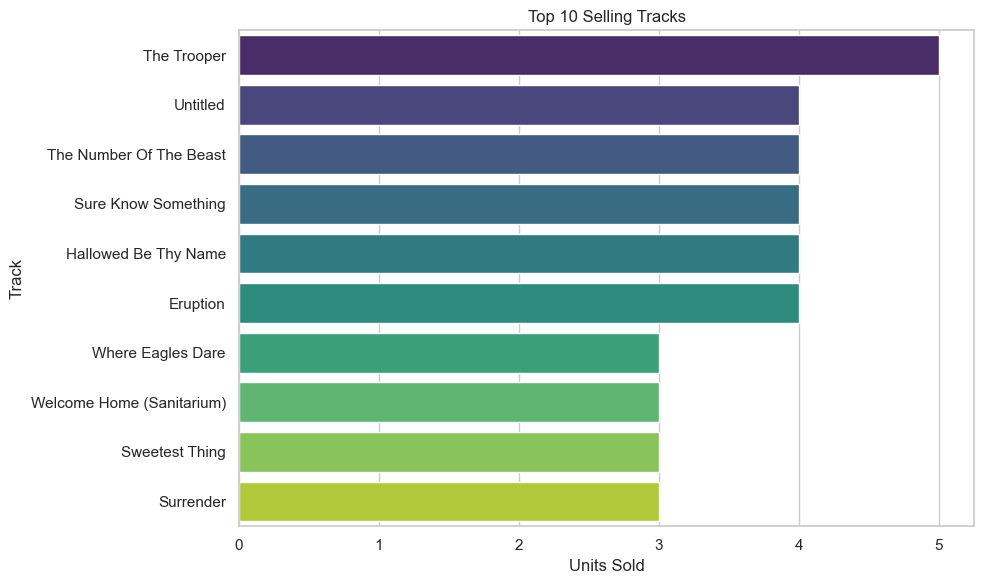

In [40]:
plt.figure(figsize=(10,6))
sb.barplot(data=df_products.head(10), y='Name', x='Total_Sold', palette='viridis')
plt.title('Top 10 Selling Tracks')
plt.xlabel('Units Sold')
plt.ylabel('Track')
plt.tight_layout()
plt.show()

## Revenue per Region → *"Which countries generate the most revenue?"*

In [5]:
query_region = """
SELECT Customer.Country, SUM(InvoiceLine.Quantity * InvoiceLine.UnitPrice) AS Total_Revenue
FROM Invoice
JOIN Customer ON Invoice.CustomerId = Customer.CustomerId
JOIN InvoiceLine ON Invoice.InvoiceId = InvoiceLine.InvoiceId
GROUP BY Customer.Country
ORDER BY Total_Revenue DESC;
"""
df_region = pd.read_sql_query(query_region, conn)
df_region

,Country,Total_Revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


C:\Users\Jinzo\AppData\Local\Temp\ipykernel_4512\4290789119.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=df_region.head(15), y='Country', x='Total_Revenue', palette='mako')


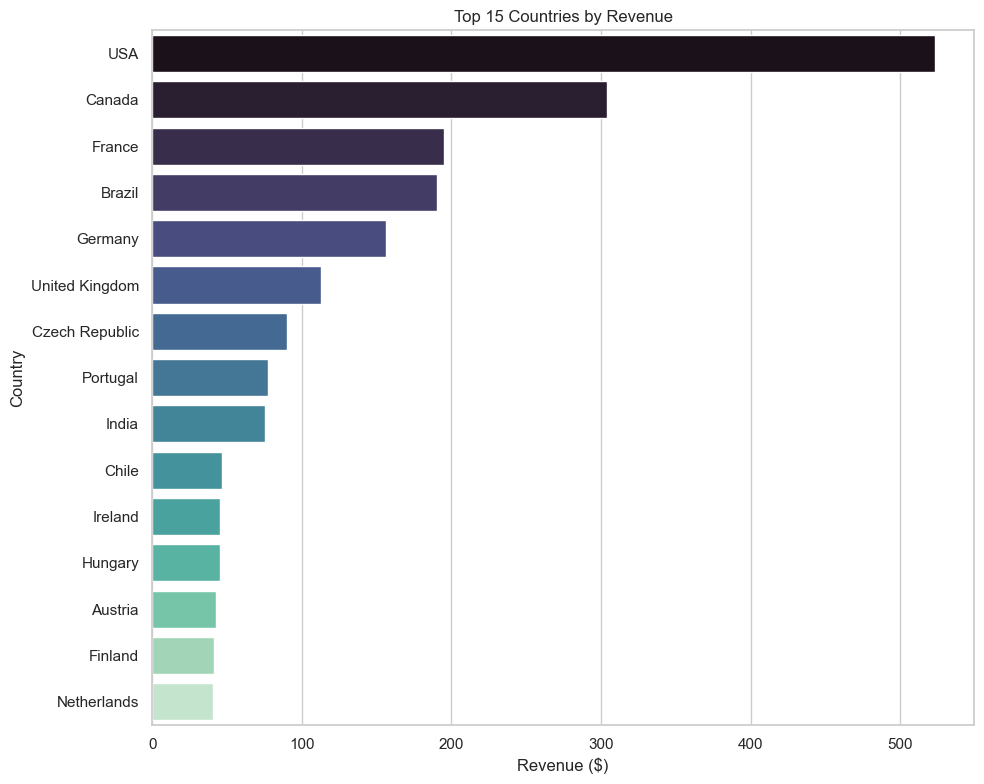

In [41]:
plt.figure(figsize=(10,8))
sb.barplot(data=df_region.head(15), y='Country', x='Total_Revenue', palette='mako')
plt.title('Top 15 Countries by Revenue')
plt.xlabel('Revenue ($)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

## Genre-per-Country Ranking → *"Which music genres are most popular in each country, and how do regional preferences differ?"*

In [30]:
query = """
WITH genre_country_sales AS (
    SELECT 
        Customer.Country,
        Genre.Name AS Genre,
        SUM(InvoiceLine.Quantity) AS Total_Sold
    FROM InvoiceLine
    JOIN Track ON InvoiceLine.TrackId = Track.TrackId
    JOIN Genre ON Track.GenreId = Genre.GenreId
    JOIN Invoice ON InvoiceLine.InvoiceId = Invoice.InvoiceId
    JOIN Customer ON Invoice.CustomerId = Customer.CustomerId
    GROUP BY Customer.Country, Genre.Name
)
SELECT *,
    RANK() OVER (PARTITION BY Country ORDER BY Total_Sold DESC) AS Genre_Rank
FROM genre_country_sales
ORDER BY Country, Genre_Rank;
"""
df_genre_country = pd.read_sql_query(query, conn)
df_genre_country

,Country,Genre,Total_Sold,Genre_Rank
0,Argentina,Alternative & Punk,9,1
1,Argentina,Rock,9,1
2,Argentina,Latin,8,3
3,Argentina,Metal,7,4
4,Argentina,Easy Listening,2,5
...,...,...,...,...
232,United Kingdom,Jazz,4,6
233,United Kingdom,Hip Hop/Rap,3,7
234,United Kingdom,Pop,2,8
235,United Kingdom,R&B/Soul,2,8


C:\Users\Jinzo\AppData\Local\Temp\ipykernel_4512\1065395567.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=usa_genres, y='Genre', x='Total_Sold', palette='rocket')


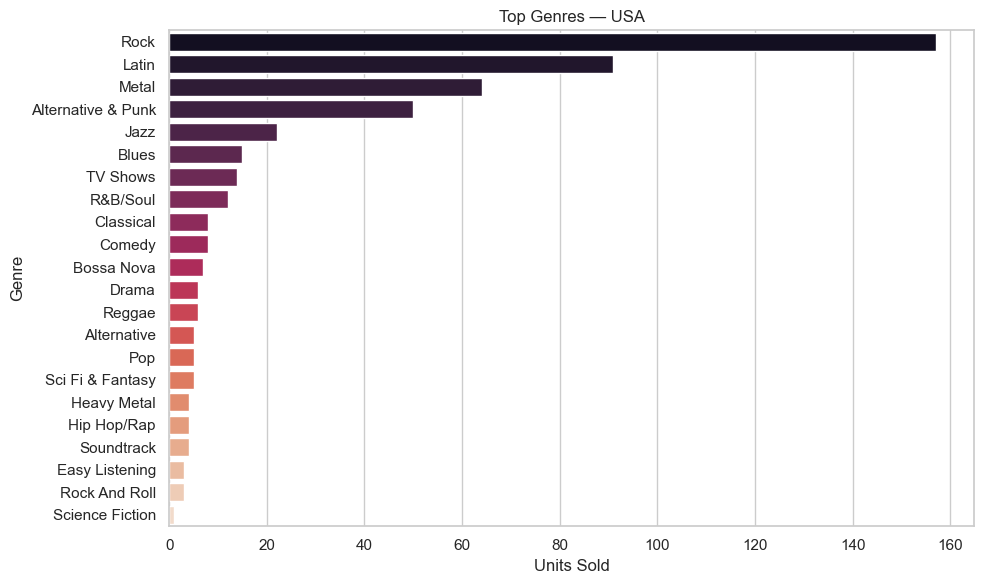

In [42]:
usa_genres = df_genre_country[df_genre_country['Country'] == 'USA'].sort_values('Total_Sold', ascending=False)

plt.figure(figsize=(10,6))
sb.barplot(data=usa_genres, y='Genre', x='Total_Sold', palette='rocket')
plt.title('Top Genres — USA')
plt.xlabel('Units Sold')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

## Month-over-Month Revenue Growth → *"Is revenue trending up or down month to month, and where are the biggest swings?"*

In [27]:
query = """
--Month-over-Month Revenue Growth
WITH monthly_revenue AS(
    SELECT 
        strftime('%Y-%m', Invoice.InvoiceDate) AS Month,
        SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity) AS Total_Revenue
    FROM Invoice
    JOIN InvoiceLine ON Invoice.InvoiceId = InvoiceLine.InvoiceId
    GROUP BY Month
)
SELECT 
    Month,
    LAG(TOTAL_Revenue) OVER (ORDER BY Month) AS Prev_Month_Revenue,
    Round(
        (Total_Revenue - LAG(Total_Revenue) OVER (ORDER BY Month)) * 100.0
        / LAG(Total_Revenue) OVER (ORDER BY Month), 2
    ) AS MoM_Growth_Percent
FROM monthly_revenue 
ORDER BY Month;
"""
df_mom = pd.read_sql_query(query, conn)
df_mom

,Month,Prev_Month_Revenue,MoM_Growth_Percent
0,2009-01,NaN,NaN
1,2009-02,35.64,5.56
2,2009-03,37.62,0.00
3,2009-04,37.62,0.00
4,2009-05,37.62,0.00
5,2009-06,37.62,0.00
6,2009-07,37.62,0.00
7,2009-08,37.62,0.00
8,2009-09,37.62,0.00
9,2009-10,37.62,0.00


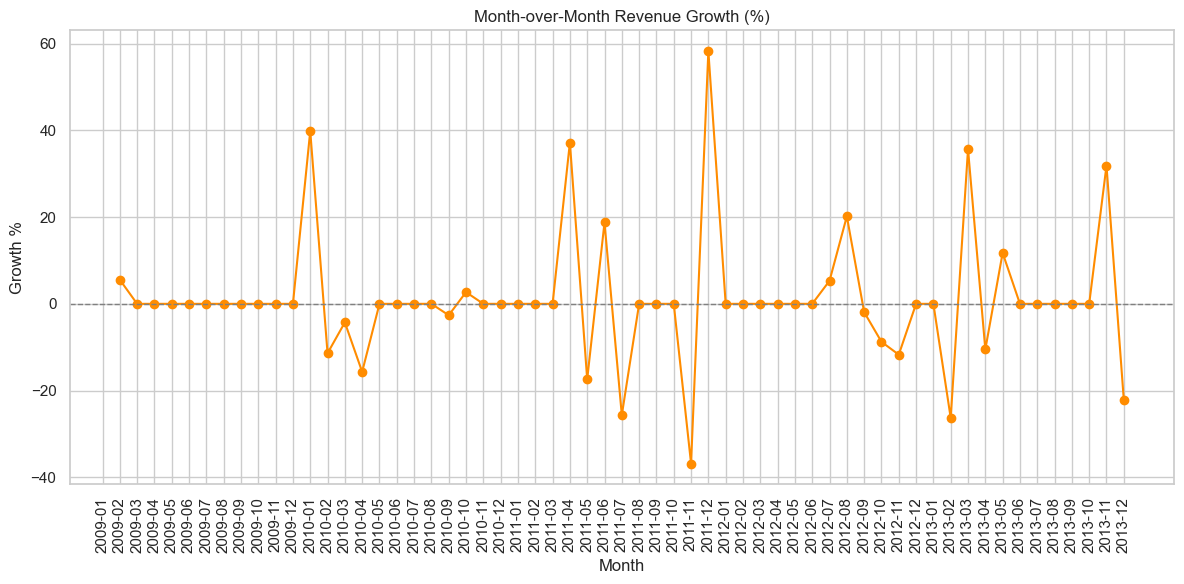

In [43]:
plt.figure(figsize=(12,6))
plt.plot(df_mom['Month'], df_mom['MoM_Growth_Percent'], marker='o', color='darkorange')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Month-over-Month Revenue Growth (%)')
plt.xlabel('Month')
plt.ylabel('Growth %')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Cumulative Revenue Over Time → *"How has total revenue accumulated over the life of the business?"*

In [28]:
query = """
SELECT 
    strftime('%Y-%m', Invoice.InvoiceDate) AS Month,
    SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity) AS Monthly_Revenue,
    SUM(SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity)) OVER (ORDER BY strftime('%Y-%m', Invoice.InvoiceDate)) AS Running_Total_Revenue
FROM Invoice
JOIN InvoiceLine ON Invoice.InvoiceId = InvoiceLine.InvoiceId
GROUP BY Month
ORDER BY Month;
"""
df_running = pd.read_sql_query(query, conn)
df_running

,Month,Monthly_Revenue,Running_Total_Revenue
0,2009-01,35.64,35.64
1,2009-02,37.62,73.26
2,2009-03,37.62,110.88
3,2009-04,37.62,148.50
4,2009-05,37.62,186.12
5,2009-06,37.62,223.74
6,2009-07,37.62,261.36
7,2009-08,37.62,298.98
8,2009-09,37.62,336.60
9,2009-10,37.62,374.22


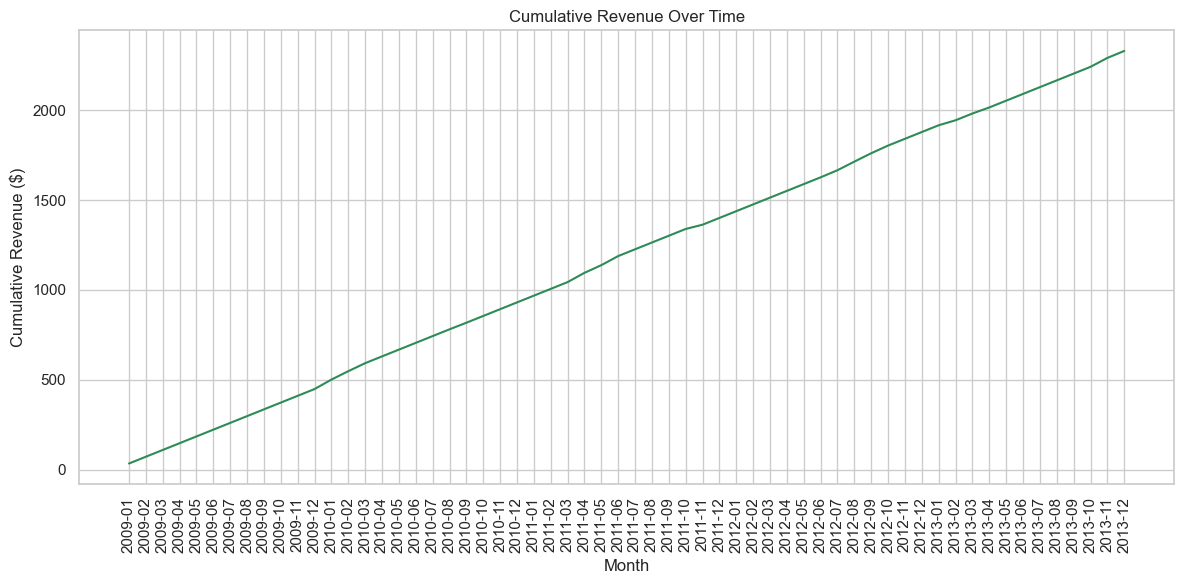

In [44]:
plt.figure(figsize=(12,6))
plt.plot(df_running['Month'], df_running['Running_Total_Revenue'], color='seagreen')
plt.title('Cumulative Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Cumulative Revenue ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Customer RFM Segmentation → *"Which customers are the most valuable, and which are at risk of churning?"*

In [29]:
query = """
WITH customer_rfm AS (
   SELECT 
       Customer.CustomerId,
       Customer.FirstName || ' ' || Customer.LastName AS CustomerName,
       julianday('2013-12-31') - julianday(MAX(Invoice.InvoiceDate)) AS Recency_Days,
       COUNT(DISTINCT Invoice.InvoiceId) AS Frequency,
       SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity) AS Monetary
   FROM Customer
   JOIN Invoice ON Customer.CustomerId = Invoice.CustomerId 
   Join InvoiceLine ON Invoice.InvoiceId = InvoiceLine.InvoiceId
   GROUP BY Customer.CustomerId, CustomerName 
)
SELECT 
   CustomerId,
   CustomerName,
   ROUND(Recency_Days) AS Recency_Days,
   Frequency,
   ROUND(Monetary, 2) AS Monetary,
   NTILE(4) OVER (ORDER BY Recency_Days ASC) AS Recency_Score,
   NTILE(4) OVER (ORDER BY Frequency DESC) AS Frequency_Score,
   NTILE(4) OVER (ORDER BY Monetary DESC) AS Monetary_Score
FROM customer_rfm 
ORDER BY Monetary DESC;
"""
df_rfm = pd.read_sql_query(query, conn)
df_rfm

,CustomerId,CustomerName,Recency_Days,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score
0,6,Helena Holý,48.0,7,49.62,1,1,1
1,26,Richard Cunningham,270.0,7,47.62,3,1,1
2,57,Luis Rojas,443.0,7,46.62,4,1,1
3,46,Hugh O'Reilly,57.0,7,45.62,1,1,1
4,45,Ladislav Kovács,164.0,7,45.62,2,1,1
5,24,Frank Ralston,133.0,7,43.62,2,1,1
6,37,Fynn Zimmermann,211.0,7,43.62,3,1,1
7,28,Julia Barnett,226.0,7,43.62,3,1,1
8,25,Victor Stevens,26.0,7,42.62,1,1,1
9,7,Astrid Gruber,195.0,7,42.62,3,1,1


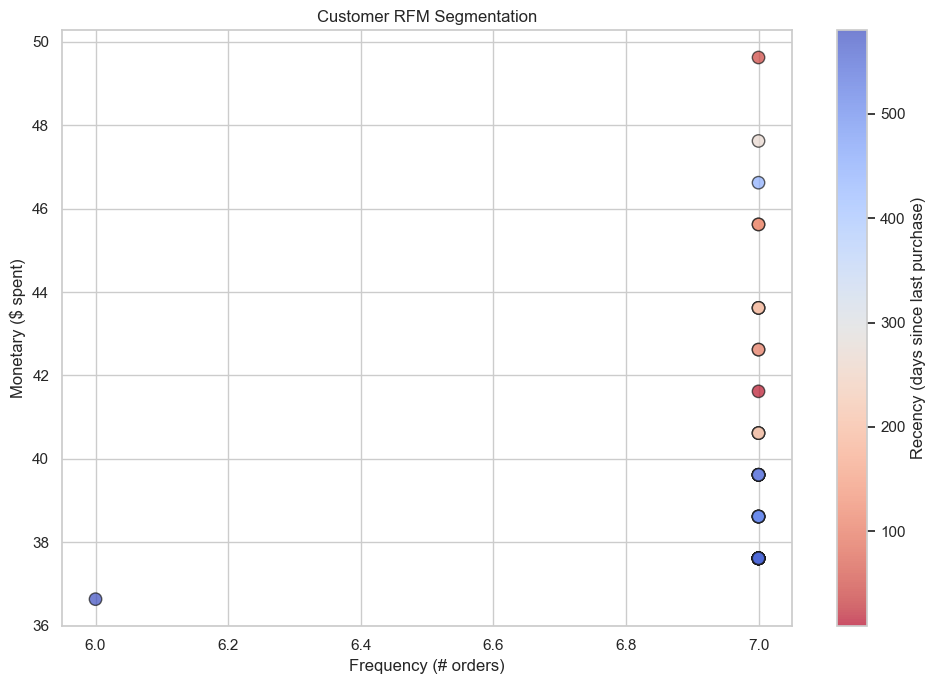

In [45]:
plt.figure(figsize=(10,7))
scatter = plt.scatter(
    df_rfm['Frequency'], df_rfm['Monetary'],
    c=df_rfm['Recency_Days'], cmap='coolwarm_r',
    s=80, alpha=0.7, edgecolor='k'
)
plt.colorbar(scatter, label='Recency (days since last purchase)')
plt.title('Customer RFM Segmentation')
plt.xlabel('Frequency (# orders)')
plt.ylabel('Monetary ($ spent)')
plt.tight_layout()
plt.show()

## Unsold Catalog Tracks → *"Which tracks in the catalog have never sold — candidates for removal, bundling, or promotion?"*

In [31]:
query = """
SELECT 
    Track.TrackId,
    Track.Name,
    Track.GenreId
FROM Track
LEFT JOIN InvoiceLine ON Track.TrackId = InvoiceLine.TrackId
WHERE InvoiceLine.TrackId IS NULL;
"""
df_unsold = pd.read_sql_query(query, conn)
df_unsold

,TrackId,Name,GenreId
0,7,Let's Get It Up,1
1,11,C.O.D.,1
2,17,Let There Be Rock,1
3,18,Bad Boy Boogie,1
4,22,Whole Lotta Rosie,1
...,...,...,...
1514,3497,"Erlkonig, D.328",24
1515,3498,"Concerto for Violin, Strings and Continuo in G...",24
1516,3501,"L'orfeo, Act 3, Sinfonia (Orchestra)",24
1517,3502,"Quintet for Horn, Violin, 2 Violas, and Cello ...",24


## Sales Rep Performance → *"Which support reps drive the most revenue through their assigned customers?"*

In [32]:
query = """
SELECT 
    Employee.EmployeeId,
    Employee.FirstName || ' ' || Employee.LastName AS RepName,
    COUNT(DISTINCT Invoice.InvoiceId) AS Total_Orders,
    ROUND(SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity), 2) AS Total_Revenue,
    RANK() OVER (ORDER BY SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity) DESC) AS Rep_Rank
FROM Employee
JOIN Customer ON Employee.EmployeeId = Customer.SupportRepId
JOIN Invoice ON Customer.CustomerId = Invoice.CustomerId
JOIN InvoiceLine ON Invoice.InvoiceId = InvoiceLine.InvoiceId
GROUP BY Employee.EmployeeId, RepName
ORDER BY Rep_Rank;
"""
df_reps = pd.read_sql_query(query, conn)
df_reps

,EmployeeId,RepName,Total_Orders,Total_Revenue,Rep_Rank
0,3,Jane Peacock,146,833.04,1
1,4,Margaret Park,140,775.40,2
2,5,Steve Johnson,126,720.16,3
